# 02 · Variables et découpage temporel

**Question : quelles variables donner au modèle, et comment évaluer sans tricher ?**

Tout le code vient de `src/features.py` et `src/data.py` : le notebook utilise exactement le code de production.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams.update({"figure.figsize": (12, 4), "axes.grid": True, "grid.alpha": 0.3})

from src.config import load_params
from src.data import load_dataset, temporal_split
from src.features import FEATURE_COLUMNS

data = load_dataset()
print("Variables :", FEATURE_COLUMNS)
data[["timestamp", "consommation_mw", *FEATURE_COLUMNS]].tail()

Variables : ['hour', 'minute', 'dayofweek', 'month', 'dayofyear', 'lag_48', 'lag_96', 'lag_336']


,timestamp,consommation_mw,hour,minute,dayofweek,month,dayofyear,lag_48,lag_96,lag_336
240222,2026-09-23 18:30:00+00:00,47261.0,20,30,2,9,266,47012.0,46781.0,47375.0
240223,2026-09-23 19:00:00+00:00,45644.0,21,0,2,9,266,45124.0,44716.0,45635.0
240224,2026-09-23 19:30:00+00:00,44219.0,21,30,2,9,266,43251.0,43117.0,44474.0
240225,2026-09-23 20:00:00+00:00,42844.0,22,0,2,9,266,41992.0,42350.0,43038.0
240226,2026-09-23 20:30:00+00:00,43185.0,22,30,2,9,266,42475.0,42468.0,43680.0


## Pourquoi seulement des lags d'au moins 24 h ?

Le besoin métier est une **prévision day-ahead** : la veille, on prédit les 48 demi-heures du lendemain. Au moment de prédire demain 18 h, la consommation de demain 17 h 30 (`lag_1`) **n'est pas connue**.

- avec `lag_1`, le modèle obtient un excellent score… sur une tâche qui n'est pas la nôtre (prévision à 30 min) : c'est une **fuite d'information** ;
- avec `lag_48`, `lag_96`, `lag_336`, toutes les valeurs sont connues la veille : la journée entière se prédit d'un coup, sans réinjecter ses propres prévisions.

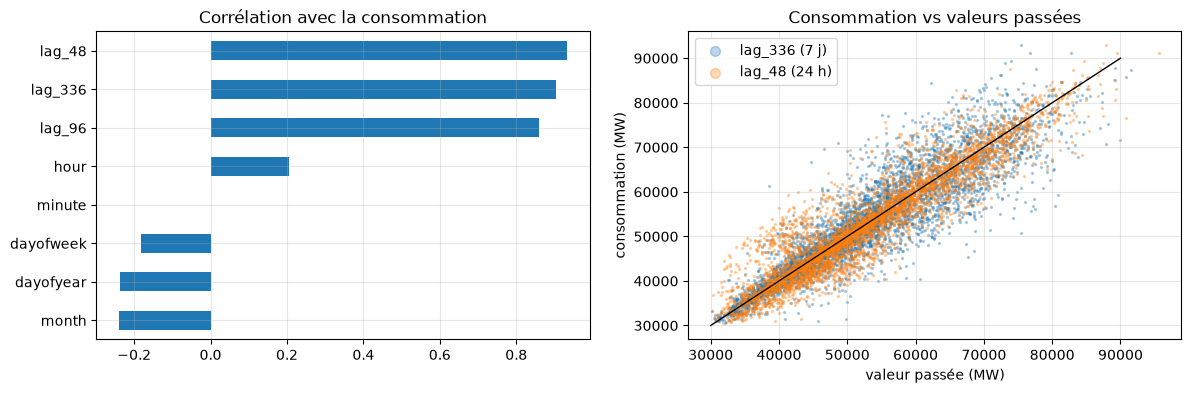

In [2]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
correlations = data[FEATURE_COLUMNS + ["consommation_mw"]].corr()["consommation_mw"].drop("consommation_mw").sort_values()
correlations.plot.barh(ax=ax1, title="Corrélation avec la consommation")

sample = data.sample(5000, random_state=0)
ax2.scatter(sample["lag_336"], sample["consommation_mw"], s=2, alpha=0.3, label="lag_336 (7 j)")
ax2.scatter(sample["lag_48"], sample["consommation_mw"], s=2, alpha=0.3, label="lag_48 (24 h)")
ax2.plot([30000, 90000], [30000, 90000], color="black", linewidth=1)
ax2.set(title="Consommation vs valeurs passées", xlabel="valeur passée (MW)", ylabel="consommation (MW)")
ax2.legend(markerscale=5);

Les lags sont très corrélés à la cible, mais la relation n'est pas parfaite (week-ends, jours fériés, météo) : c'est ce que le modèle devra apprendre avec le calendrier. `hour` a une corrélation linéaire faible alors qu'elle est essentielle (notebook 01) : la relation est **non linéaire**, d'où l'encodage one-hot pour la régression linéaire et l'intérêt des arbres.

## Découpage temporel

Paramètres dans `params.yaml` (suivis par DVC) :

- **test** : les 3 derniers mois, jamais utilisés pour entraîner ni choisir ;
- **validation** : le mois précédent, pour choisir le modèle et arrêter l'entraînement (early stopping) ;
- **train** : tout le reste, avant.

In [3]:
split = load_params()["split"]
fit, validation, test = temporal_split(data, split)

assert fit["timestamp"].max() < validation["timestamp"].min()
assert validation["timestamp"].max() < test["timestamp"].min()

pd.DataFrame({
    name: {"début": frame["timestamp"].min().date(), "fin": frame["timestamp"].max().date(), "lignes": len(frame)}
    for name, frame in {"train": fit, "validation": validation, "test": test}.items()
}).T

,début,fin,lignes
train,2013-01-07,2026-05-23,234322
validation,2026-05-23,2026-06-23,1488
test,2026-06-23,2026-09-23,4417


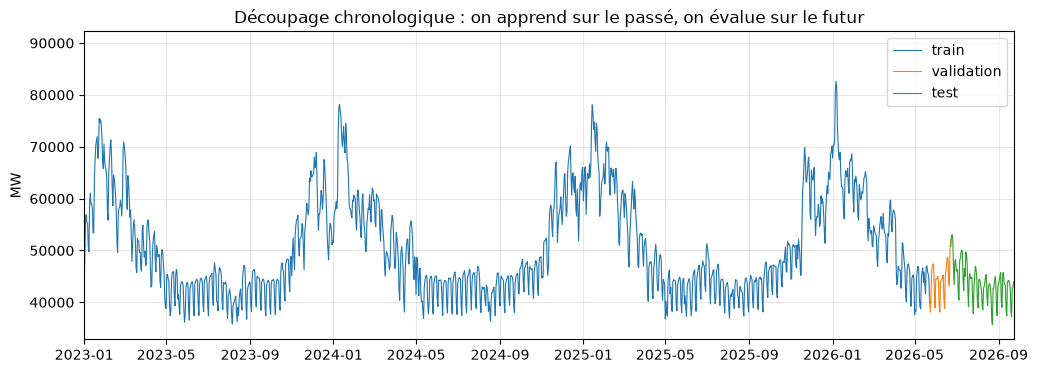

In [4]:
fig, ax = plt.subplots()
for name, frame in {"train": fit, "validation": validation, "test": test}.items():
    daily = frame.set_index("timestamp")["consommation_mw"].resample("D").mean()
    ax.plot(daily.index, daily, label=name, linewidth=0.8)
ax.set(title="Découpage chronologique : on apprend sur le passé, on évalue sur le futur", ylabel="MW")
ax.set_xlim(pd.Timestamp("2023-01-01", tz="UTC"), test["timestamp"].max())
ax.legend();

Aucun mélange aléatoire : le modèle est évalué exactement comme il sera utilisé, sur des données **postérieures** à son entraînement. Le test inclut les données temps réel les plus récentes de l'API RTE.